In [1]:
import os
import cv2
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC_DIR = ROOT / "src"
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"

os.chdir(ROOT)

sys.path.insert(0, str(SRC_DIR))

from vae_model import PlainVAE, ResidualVAE

In [2]:
# configuration
MAIN_DATA_PATH = "./data/open_loop/"
CKPT_DIR       = "checkpoints"
LATENT_DIMS    = [2, 3, 4, 6, 8, 16, 32, 64]
MODEL_TYPES    = ["PlainVAE", "ResidualVAE"]
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
TRAIN_SPLIT    = 0.80
BATCH_SIZE     = 128
N_RECON_SAMPLES = 20   # number of reconstruction grid figures to save
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
class flow_image_ds(Dataset):
    def __init__(self, paths):
        self.samples = []
        for path in paths:
            snap_files = sorted([f for f in os.listdir(path)
                                 if f.endswith(".png") or f.endswith(".jpg")])
            for snap in snap_files:
                self.samples.append(os.path.join(path, snap))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.samples[idx]), cv2.COLOR_BGR2RGB)
        img = img[87:215, 46:366, :]
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        return img


folder_paths = [f for f in sorted(os.listdir(MAIN_DATA_PATH))
                if "Amp" in f and "Freq" in f]
full_paths   = [os.path.join(MAIN_DATA_PATH, f) for f in folder_paths]

train_len  = int(TRAIN_SPLIT * len(full_paths))
val_paths  = full_paths[train_len:]

val_ds     = flow_image_ds(val_paths)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)

print(f"Val samples: {len(val_ds)}")

Val samples: 4800


In [4]:
def load_model(model_type, latent_dim, ckpt_dir, device):
    path = os.path.join(ckpt_dir, f"best_{model_type}_d{latent_dim}.pth")
    if not os.path.exists(path):
        print(f"  WARNING: checkpoint not found — {path}")
        return None
    ckpt  = torch.load(path, map_location=device)
    ModelClass = PlainVAE if model_type == "PlainVAE" else ResidualVAE
    model = ModelClass(latent_dim=latent_dim).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt


def compute_val_recon(model, val_loader, device):
    total_recon = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch        = batch.to(device)
            x_hat, _, _  = model(batch)
            total_recon += F.mse_loss(x_hat, batch, reduction="mean").item()
    return total_recon / len(val_loader)


# load all 16 models and compute val recon loss
results = {}   # results[(model_type, latent_dim)] = {"val_recon": float, "ckpt": dict}

for model_type in MODEL_TYPES:
    for d in LATENT_DIMS:
        out = load_model(model_type, d, CKPT_DIR, DEVICE)
        if out is None:
            continue
        model, ckpt = out
        val_recon   = compute_val_recon(model, val_loader, DEVICE)
        results[(model_type, d)] = {
            "val_recon":    val_recon,
            "saved_recon":  ckpt.get("val_recon", None),
            "saved_total":  ckpt.get("val_total", None),
            "epoch":        ckpt.get("epoch", None),
        }
        print(f"{model_type:14s}  d={d:2d}  "
              f"val_recon={val_recon:.6f}  "
              f"best_epoch={ckpt.get('epoch', '?')}")

/tmp/ipykernel_285916/937800534.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(path, map_location=device)
/home/krafiq/.local/lib/python3.10/site-pac

PlainVAE        d= 2  val_recon=0.010484  best_epoch=181
PlainVAE        d= 3  val_recon=0.006234  best_epoch=182
PlainVAE        d= 4  val_recon=0.004171  best_epoch=215
PlainVAE        d= 6  val_recon=0.003213  best_epoch=242
PlainVAE        d= 8  val_recon=0.002784  best_epoch=243
PlainVAE        d=16  val_recon=0.001909  best_epoch=207
PlainVAE        d=32  val_recon=0.001325  best_epoch=246
PlainVAE        d=64  val_recon=0.001060  best_epoch=241
ResidualVAE     d= 2  val_recon=0.010293  best_epoch=65
ResidualVAE     d= 3  val_recon=0.005780  best_epoch=224
ResidualVAE     d= 4  val_recon=0.004089  best_epoch=210
ResidualVAE     d= 6  val_recon=0.003182  best_epoch=226
ResidualVAE     d= 8  val_recon=0.002577  best_epoch=250
ResidualVAE     d=16  val_recon=0.001887  best_epoch=190
ResidualVAE     d=32  val_recon=0.001382  best_epoch=202
ResidualVAE     d=64  val_recon=0.001121  best_epoch=212


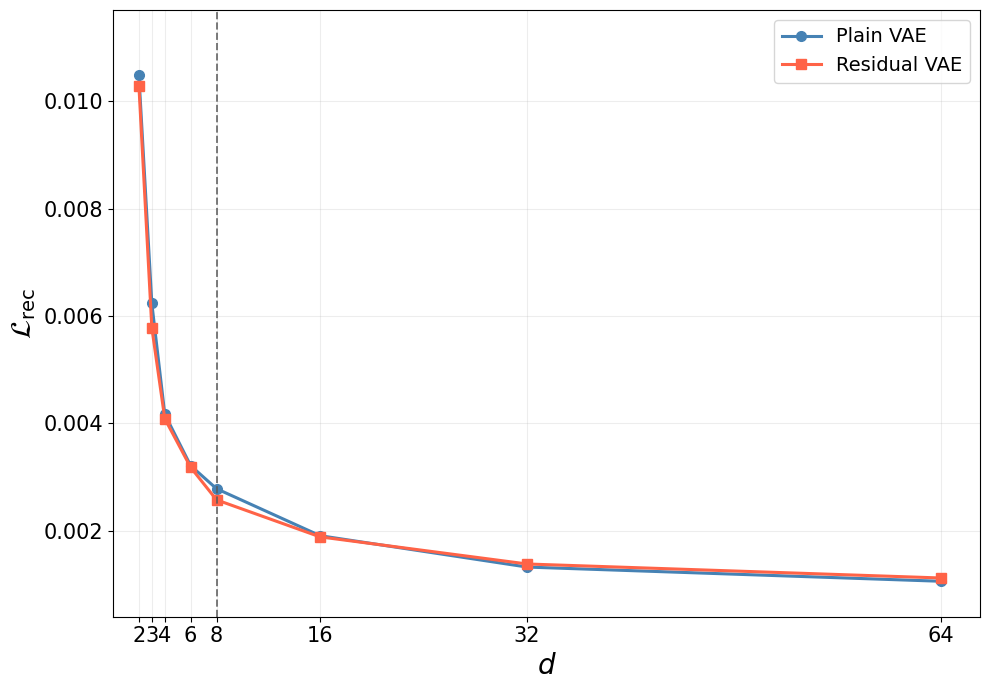

Saved: val_recon_vs_latent_dim.png


In [5]:
# Validation reconstruction loss vs latent dimension

plain_recon = [results.get(("PlainVAE", d), {}).get("val_recon", np.nan) for d in LATENT_DIMS]
resid_recon = [results.get(("ResidualVAE", d), {}).get("val_recon", np.nan) for d in LATENT_DIMS]

fig, ax = plt.subplots(figsize=(10, 7.0))

ax.plot(LATENT_DIMS, plain_recon, marker="o", markersize=7, linewidth=2.2,
        color="steelblue", label="Plain VAE")
ax.plot(LATENT_DIMS, resid_recon, marker="s", markersize=7, linewidth=2.2,
        color="tomato", label="Residual VAE")

# Selected latent dimension
ax.axvline(8, linestyle="--", linewidth=1.4, color="0.35", alpha=0.8)

ax.set_xlabel(r"$d$", fontsize=20)
ax.set_ylabel(r"$\mathcal{L}_{\mathrm{rec}}$", fontsize=20)

ax.set_xticks(LATENT_DIMS)
ax.tick_params(axis="both", which="major", labelsize=15)

ax.legend(fontsize=14, loc="upper right", frameon=True)
ax.grid(True, alpha=0.22)

ax.set_xlim(0.001, 67)
ax.set_ylim(0.00040, 0.0117)

plt.tight_layout()
plt.savefig("val_recon_vs_latent_dim.png", dpi=500, bbox_inches="tight")
plt.show()

print("Saved: val_recon_vs_latent_dim.png")

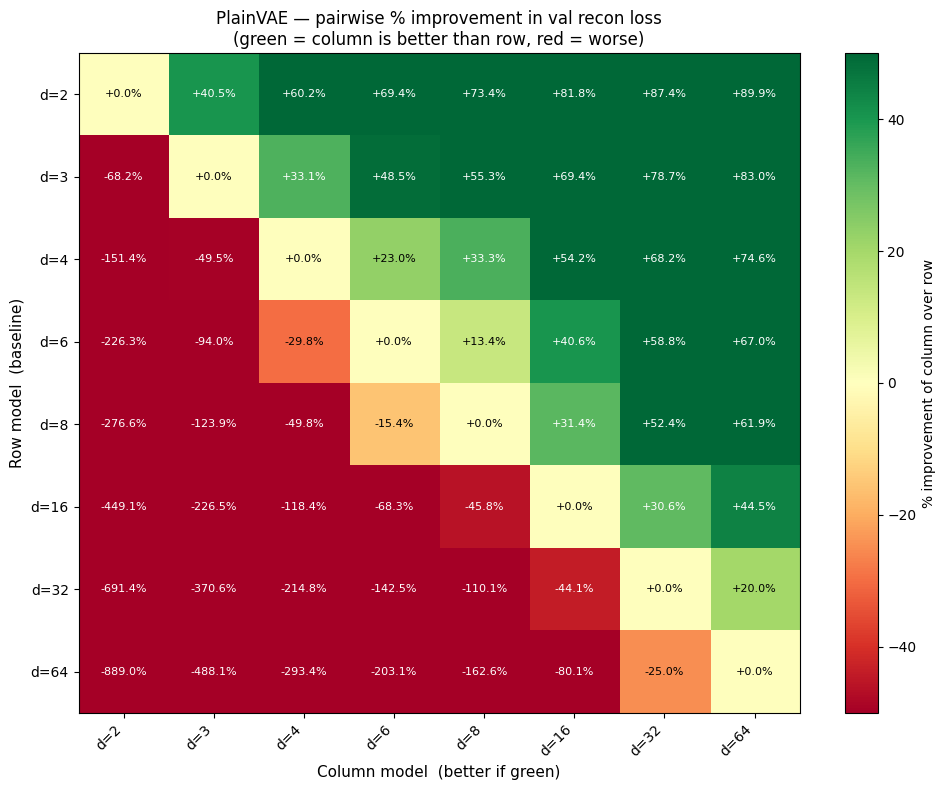

Saved: pairwise_improvement_PlainVAE.png


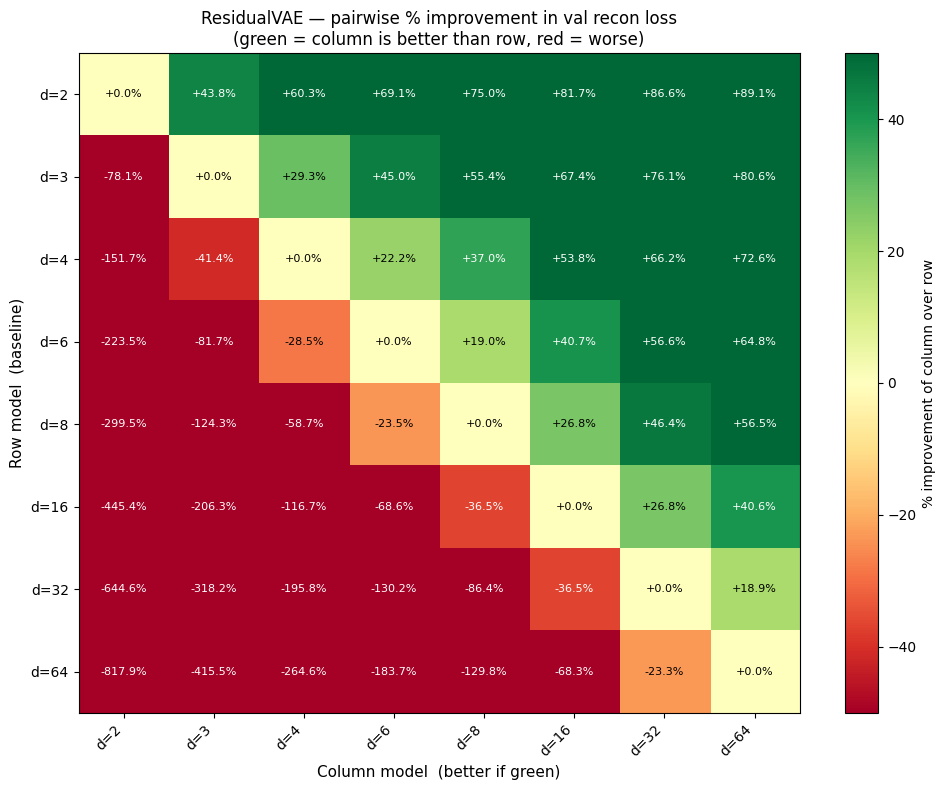

Saved: pairwise_improvement_ResidualVAE.png


In [6]:
# Plot 2: pairwise percentage improvement matrix
# entry [i, j] = how much better is d_j vs d_i in percent
# positive = d_j is better (lower loss), negative = d_j is worse

for model_type in MODEL_TYPES:
    losses = np.array([results.get((model_type, d), {}).get("val_recon", np.nan)
                       for d in LATENT_DIMS])

    n   = len(LATENT_DIMS)
    mat = np.full((n, n), np.nan)
    for i in range(n):
        for j in range(n):
            if not np.isnan(losses[i]) and not np.isnan(losses[j]) and losses[i] > 0:
                mat[i, j] = (losses[i] - losses[j]) / losses[i] * 100.0

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(mat, cmap="RdYlGn", vmin=-50, vmax=50, aspect="auto")
    plt.colorbar(im, ax=ax, label="% improvement of column over row")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"d={d}" for d in LATENT_DIMS], rotation=45, ha="right")
    ax.set_yticklabels([f"d={d}" for d in LATENT_DIMS])
    ax.set_xlabel("Column model  (better if green)", fontsize=11)
    ax.set_ylabel("Row model  (baseline)", fontsize=11)
    ax.set_title(f"{model_type} — pairwise % improvement in val recon loss\n"
                 f"(green = column is better than row, red = worse)", fontsize=12)

    for i in range(n):
        for j in range(n):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f"{mat[i,j]:+.1f}%",
                        ha="center", va="center", fontsize=8,
                        color="black" if abs(mat[i, j]) < 30 else "white")

    plt.tight_layout()
    fname = f"pairwise_improvement_{model_type}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

In [7]:
# # Plot 3: reconstruction grids — 3 random val samples
# # layout: rows = latent dims (8), cols = Plain | Residual (2) + original (1)
# # col 0 = original, col 1 = PlainVAE, col 2 = ResidualVAE

# # pre-load all models
# models = {}
# for model_type in MODEL_TYPES:
#     for d in LATENT_DIMS:
#         out = load_model(model_type, d, CKPT_DIR, DEVICE)
#         if out is not None:
#             models[(model_type, d)] = out[0]

# # pick fixed random indices for reproducibility
# np.random.seed(42)
# all_images    = []
# for batch in val_loader:
#     all_images.append(batch)
#     if len(all_images) * BATCH_SIZE >= 500:
#         break
# all_images  = torch.cat(all_images, dim=0)
# sample_idxs = np.random.choice(len(all_images), N_RECON_SAMPLES, replace=False)

# for fig_idx, img_idx in enumerate(sample_idxs):
#     orig = all_images[img_idx].to(DEVICE)

#     n_rows = len(LATENT_DIMS)
#     n_cols = 3   # original | PlainVAE | ResidualVAE

#     fig = plt.figure(figsize=(n_cols * 5, n_rows * 2.5))
#     gs  = gridspec.GridSpec(n_rows, n_cols,
#                             hspace=0.05, wspace=0.05)

#     col_titles = ["Original", "PlainVAE", "ResidualVAE"]

#     for row_idx, d in enumerate(LATENT_DIMS):
#         recons = [orig.cpu()]

#         for model_type in MODEL_TYPES:
#             m = models.get((model_type, d))
#             if m is not None:
#                 with torch.no_grad():
#                     x_hat, _, _ = m(orig.unsqueeze(0))
#                 recons.append(x_hat.squeeze(0).cpu())
#             else:
#                 recons.append(torch.zeros_like(orig.cpu()))

#         for col_idx, img_tensor in enumerate(recons):
#             ax  = fig.add_subplot(gs[row_idx, col_idx])
#             img = np.clip(img_tensor.permute(1, 2, 0).numpy(), 0, 1)
#             ax.imshow(img)
#             ax.axis("off")

#             if row_idx == 0:
#                 ax.set_title(col_titles[col_idx], fontsize=11, fontweight="bold", pad=4)
#             if col_idx == 0:
#                 ax.set_ylabel(f"d={d}", fontsize=10, rotation=0,
#                               labelpad=30, va="center")

#     fig.suptitle(f"Reconstruction comparison — sample {fig_idx+1}",
#                  fontsize=13, y=1.01)
#     fname = f"recon_grid_sample{fig_idx+1}.png"
#     plt.savefig(fname, dpi=120, bbox_inches="tight")
#     plt.show()
#     print(f"Saved: {fname}")

In [8]:
# Summary table
print(f"{'Model':<14} {'d':>4} {'val_recon':>12} {'best_epoch':>12}")
print("-" * 46)
for model_type in MODEL_TYPES:
    for d in LATENT_DIMS:
        r = results.get((model_type, d))
        if r:
            print(f"{model_type:<14} {d:>4} {r['val_recon']:>12.6f} "
                  f"{str(r['epoch']):>12}")
    print()

print("\nRelative improvement of ResidualVAE over PlainVAE per latent dim:")
print(f"{'d':>4} {'Plain':>10} {'Residual':>10} {'Improvement':>13}")
print("-" * 42)
for d in LATENT_DIMS:
    pr = results.get(("PlainVAE",    d), {}).get("val_recon", None)
    rr = results.get(("ResidualVAE", d), {}).get("val_recon", None)
    if pr and rr:
        pct = (pr - rr) / pr * 100.0
        print(f"{d:>4} {pr:>10.6f} {rr:>10.6f} {pct:>+12.2f}%")

Model             d    val_recon   best_epoch
----------------------------------------------
PlainVAE          2     0.010484          181
PlainVAE          3     0.006234          182
PlainVAE          4     0.004171          215
PlainVAE          6     0.003213          242
PlainVAE          8     0.002784          243
PlainVAE         16     0.001909          207
PlainVAE         32     0.001325          246
PlainVAE         64     0.001060          241

ResidualVAE       2     0.010293           65
ResidualVAE       3     0.005780          224
ResidualVAE       4     0.004089          210
ResidualVAE       6     0.003182          226
ResidualVAE       8     0.002577          250
ResidualVAE      16     0.001887          190
ResidualVAE      32     0.001382          202
ResidualVAE      64     0.001121          212


Relative improvement of ResidualVAE over PlainVAE per latent dim:
   d      Plain   Residual   Improvement
------------------------------------------
   2   0.010484   

## Optimal number of clusters

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Z_PATH = "/home/krafiq/Desktop/ClusterBasedLC/Airfoil/Plain_VAE/latent_artefacts/all_z.npy"
Z = np.load(Z_PATH)
print(f"loaded latents: {Z.shape}")           # expect [N, 8]

K_RANGE = list(range(2, 16))
RANDOM_STATE = 42
N_INIT = 100                                    # high n_init -> stable centroids

inertia, sil = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=N_INIT,
                random_state=RANDOM_STATE)
    lab = km.fit_predict(Z)
    inertia.append(km.inertia_)
    # silhouette on a subsample if N is large (full is slow / memory-heavy)
    if Z.shape[0] > 8000:
        rng = np.random.default_rng(RANDOM_STATE)
        sub = rng.choice(Z.shape[0], 8000, replace=False)
        s = silhouette_score(Z[sub], lab[sub])
    else:
        s = silhouette_score(Z, lab)
    sil.append(s)
    print(f"K={k:2d}   inertia={km.inertia_:11.1f}   silhouette={s:.4f}")

loaded latents: (22400, 8)
K= 2   inertia=    50105.5   silhouette=0.2130
K= 3   inertia=    40012.2   silhouette=0.2399
K= 4   inertia=    32691.7   silhouette=0.2557
K= 5   inertia=    28517.1   silhouette=0.2763
K= 6   inertia=    24918.6   silhouette=0.2660
K= 7   inertia=    22841.7   silhouette=0.2549
K= 8   inertia=    20901.1   silhouette=0.2655
K= 9   inertia=    19346.1   silhouette=0.2763
K=10   inertia=    18175.3   silhouette=0.2617
K=11   inertia=    17167.7   silhouette=0.2664
K=12   inertia=    16230.4   silhouette=0.2668
K=13   inertia=    15414.8   silhouette=0.2618
K=14   inertia=    14609.3   silhouette=0.2660
K=15   inertia=    13918.6   silhouette=0.2678


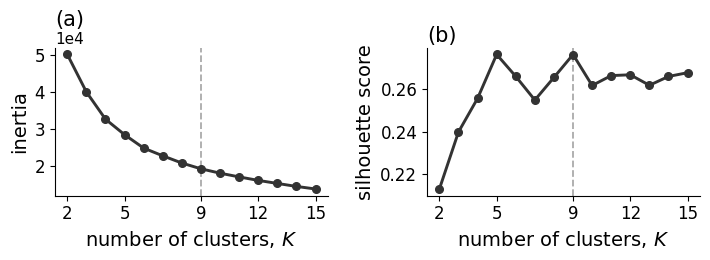

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.2, 2.7), facecolor="white")

line_color = "#333333"
guide_color = "#aaaaaa"
highlight_color = "#d4354f"

# (a) Inertia
a1.plot(K_RANGE, inertia, "o-", color=line_color, lw=2.1, ms=5.5)
a1.axvline(9, color=guide_color, ls="--", lw=1.3, zorder=0)

a1.set_xlabel(r"number of clusters, $K$", fontsize=14)
a1.set_ylabel("inertia", fontsize=14)
a1.set_title("(a)", fontsize=15, loc="left", pad=4)
a1.set_xticks([2, 5, 9, 12, 15])
a1.tick_params(axis="both", labelsize=12)

# Keep large inertia values compact
a1.ticklabel_format(axis="y", style="sci", scilimits=(4, 4))
a1.yaxis.get_offset_text().set_fontsize(11)

for spine in ("top", "right"):
    a1.spines[spine].set_visible(False)


# (b) Silhouette
a2.plot(K_RANGE, sil, "o-", color=line_color, lw=2.1, ms=5.5)
a2.axvline(9, color=guide_color, ls="--", lw=1.3, zorder=0)

kbest = K_RANGE[int(np.argmax(sil))]
sbest = max(sil)

# Subtle indication of the primary maximum
# a2.scatter(kbest, sbest, s=60, color=highlight_color, zorder=5)
# a2.annotate(r"$K=5$", xy=(kbest, sbest), xytext=(5, -16),
#             textcoords="offset points", ha="center", fontsize=11)

a2.set_xlabel(r"number of clusters, $K$", fontsize=14)
a2.set_ylabel("silhouette score", fontsize=14)
a2.set_title("(b)", fontsize=15, loc="left", pad=4)
a2.set_xticks([2, 5, 9, 12, 15])
a2.tick_params(axis="both", labelsize=12)

for spine in ("top", "right"):
    a2.spines[spine].set_visible(False)


fig.tight_layout(w_pad=2.0)
fig.savefig("kmeans_selection_inset.png", dpi=500, facecolor="white",
            bbox_inches="tight", pad_inches=0.03)
plt.show()